In [ ]:
%load_ext autoreload
%autoreload 2

In [1]:
from articulate import articulate
from omegaconf import OmegaConf
from dotenv import load_dotenv
from articulate_anything.utils.viz import (
    show_video, 
    display_code, 
    show_videos, 
    display_codes,
    show_images,
)
from articulate_anything.utils.utils import load_config, join_path
from articulate_anything.utils.cotracker_utils import make_cotracker
from PIL import Image
import json

pybullet build time: Nov 28 2023 23:52:03


In [2]:
import os
os.chdir("..")

In [3]:
API_KEY = "YOUR-ACTUAL-API-KEY"
## we have our API key stored in a .env file
## Comment the `load_dotenv` and `os.environ.get` lines if you just want to use
## your API key directly
load_dotenv()
API_KEY = os.environ.get('API_KEY')

# task = "toilet_seat_up"
task = "drawer_RL_Bench"

Let's first take a look at the ground-truth video

In [4]:
video_path = f"datasets/in-the-wild-dataset/videos/{task}.mp4"

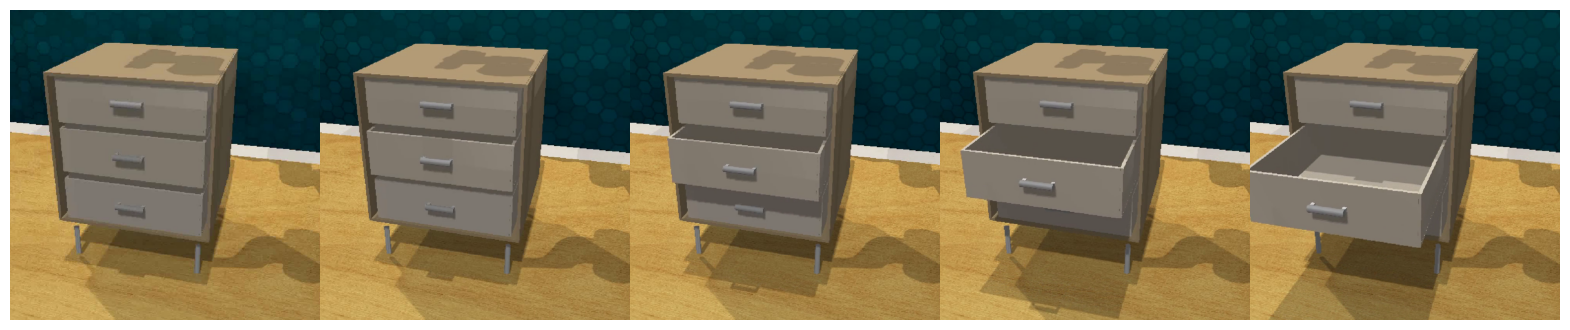

In [5]:
show_video(video_path)

We can annotate the motion in the video using Cotracker

In [6]:
cfg = load_config()

/home/link/miniconda3/envs/articulate-anything-clean/lib/python3.9/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'config': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


In [7]:
overwrite=False
aug_video = f"./datasets/in-the-wild-dataset/videos/aug_{task}.mp4"

# cfg.cotracker.max_moving_points = 10
cfg.cotracker.max_moving_points = 20
cfg.cotracker.grid_size = 30
if not os.path.exists(aug_video) or overwrite:
    cfg.cotracker.checkpoint_path = "../co-tracker/checkpoints/cotracker2.pth" ## PUT YOUR CHECKPOINT PATH HERE
    cfg.cotracker.mode = "online"
    cotracker_model = make_cotracker(cfg)
    cotracker_model.forward(video_path, **cfg.cotracker);

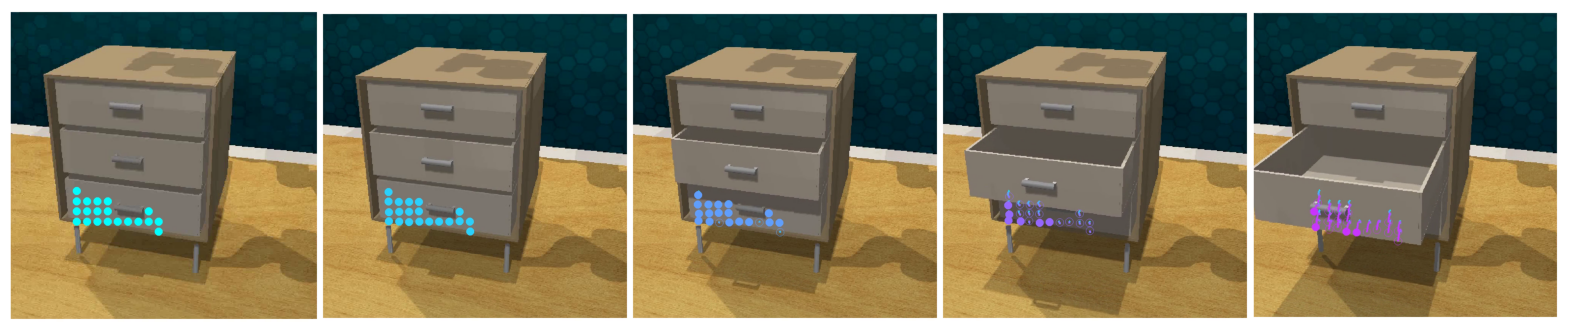

In [8]:
show_video(aug_video)

Before starting articulation, please make sure that the dataset is preprocessed by running

   ```bash
   python articulate_anything/preprocess/preprocess_partnet.py parallel={int} modality={image}
   ```
This renders a front-view image for each object in the PartNet-Mobility dataset. This is necessary for our mesh retrieval as we will compare the visual similarity between the input image or video against each rendered template object.

In [9]:
modality = "generated"
prompt = video_path

Note: currently Gemini does not support multi-modal prompt finetuning. We have to use few-shot prompting instead. It's important to pick the examples with some care for your use case.

In [10]:
cfg = load_config()
cfg.prompt = prompt
cfg.modality = modality
cfg.out_dir = join_path("results", modality, task)

cfg.segmented_mesh_dir = "datasets/segmentation_masks/drawer_multi-view"

use_cotracker = False #True # {True, False}
mode = "video"
# mode = "image"
actor_prompting_type = "basic" # {basic, incontext}
critic_prompting_type = "incontext" # {basic, incontext}

cfg.joint_actor.mode = mode
cfg.joint_actor.use_cotracker = use_cotracker
cfg.joint_actor.type = actor_prompting_type
cfg.joint_actor.targetted_affordance = True
# cfg.joint_actor.targetted_affordance = False

cfg.joint_actor.examples_dir = "datasets/multi_modal_incontext_examples/joint_actor/in_context_actor_examples_datasets" ## Put your examples here


cfg.joint_critic.mode = mode
cfg.joint_critic.use_cotracker = use_cotracker
cfg.joint_critic.type = critic_prompting_type

cfg.joint_critic.examples_dir = "datasets/multi_modal_incontext_examples/joint_critic/in_context_examples_datasets" ## Put your examples here

cfg.actor_critic.actor_only = False

## important to set correctly for the joint_critic to works properly
## this should have the same direction as the ground-truth video
cfg.simulator.flip_video = False ## flip time for suitcase
cfg.simulator.ray_tracing=False
cfg.simulator.floor_texture = "plain"


# cfg.category_selector.topk = 3
cfg.category_selector.topk = 1 ## how many top categories should we search for an object template match
# this is because PartNet-Mobility dataset categories labels are sparse and sometimes not great


cfg.obj_selector.frame_index = 0

cfg.actor_critic.max_iter = 2
cfg.model_name = "claude-3-5-sonnet-latest"#"claude-3-5-sonnet-20241022"#gemini-1.5-flash-latest"


cfg.api_key = API_KEY ## loaded from .env file

In [11]:
steps = articulate(cfg);

INFO:root:Setting seed 0
INFO:root:Starting Mesh Retrieval
INFO:root:CategorySelector: Prediction already exists. Skipping generation.
INFO:root:Starting Link Articulation
INFO:root:Creating directories: datasets/partnet-mobility-v0/dataset/generated_object and results/generated/drawer_RL_Bench/generated_object
INFO:root:Created URDF file at datasets/partnet-mobility-v0/dataset/generated_object/mobility.urdf
INFO:root:Created link summary at datasets/partnet-mobility-v0/dataset/generated_object/link_summary.txt
INFO:root:Created semantics file at datasets/partnet-mobility-v0/dataset/generated_object/semantics.txt


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


INFO:root:Successfully rendered frontview image to datasets/partnet-mobility-v0/dataset/generated_object/robot_frontview.png
INFO:root:LinkPlacementActor: Prediction already exists at results/generated/drawer_RL_Bench/generated_object/link_placement/iter_0/seed_0/link_placement.py. Skipping generation.
ERROR:root:Failed to run actor-critic loop for iteration 0, seed 0:
ERROR:root:Traceback (most recent call last):
  File "/home/link/DreMa/third_party/articulate-anything/actor_critic.py", line 60, in actor_critic_loop
    actor_result = actor_func(iteration, seed, retry_kwargs)
  File "/home/link/DreMa/third_party/articulate-anything/articulate_link.py", line 425, in <lambda>
    lambda i, s, r: actor_function(i, s, cfg, prompt, gpu_id, r),
  File "/home/link/DreMa/third_party/articulate-anything/articulate_link.py", line 341, in actor_function
    link_placement_actor.render_prediction(gpu_id)
  File "/home/link/DreMa/third_party/articulate-anything/articulate_anything/agent/actor/link

## Mesh Retrieval

Let's inspect the steps starting with the mesh retrieval

In [12]:
# mesh_retrieval = steps["Mesh Retrieval"]

In [13]:
# mesh_retrieval["Category Selection"].load_prediction()

In [14]:
# obj_selector = mesh_retrieval["Object Selection"]
# obj_selector.load_prediction()

In [15]:
# obj_selector.load_predicted_rendering()

## Link Placement

In [16]:
link_art = steps["Link Articulation"]
link_actors = link_art["Link actor"]
link_critics = link_art["Link critic"]
assert len(link_actors) == len(link_critics)
print(f"Link placement runs for {len(link_actors)} iteration(s)")

Link placement runs for 6 iteration(s)


In [17]:
link_feedbacks = [json.dumps(link_critic.load_prediction(),
                             indent=4) for link_critic in link_critics]

link_codes = [link_actor.load_prediction() for link_actor in link_actors]

link_preds = [link_actor.load_predicted_rendering() for link_actor in link_actors]

FileNotFoundError: [Errno 2] No such file or directory: 'results/generated/drawer_RL_Bench/generated_object/link_critic/iter_0/seed_0/link_critic.json'

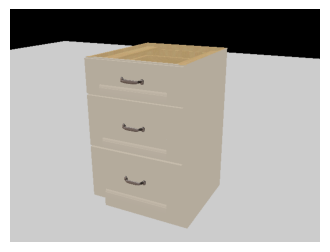

╷  
                                                                                │  
╶───────────────────────────────────────────────────────────────────────────────┼─╴
 from articulate_anything.api.odio_urdf import *                                │  
                                                                                │  
 def partnet_44962(input_dir, links):                                           │  
     pred_robot = Robot(input_dir=input_dir, name="cabinet")                    │  
     pred_robot.add_link(links['base'])                                         │  
     pred_robot.add_link(links['furniture_body'])                               │  
     pred_robot.add_joint(Joint("base_to_furniture_body",                       │  
                          Parent("base"),                                       │  
                          Child("furniture_body"),                              │  
                          type="fixed"),                                        │  
                          )                                                     │  
                                                                                │  
     # Add the drawers and place them in front of the furniture body            │  
     for drawer_idx in range(3):                                                │  
         drawer_link = "drawer" if drawer_idx == 0 else f"drawer_{drawer_idx+1}"│  
         pred_robot.add_link(links[drawer_link])                                │  
         pred_robot.place_relative_to(drawer_link, 'furniture_body',            │  
                                      placement="front",                        │  
                                      clearance=0.0)                            │  
     return pred_robot                                                          │  
                                                                                ╵

╷  
                                                                              │  
╶─────────────────────────────────────────────────────────────────────────────┼─╴
 {                                                                            │  
     "realism_rating": "10",                                                  │  
     "description": "The prediction is visually identical to the groundtruth."│  
 }                                                                            │  
                                                                              ╵

In [ ]:
show_images(link_preds)
display_codes(link_codes)
display_codes(link_feedbacks)

Note: 
1. some object part names need relabeling because PartNet-Mobility part labeling is not great. For example, a lid's pump rod would be labeled as `lid` or a door knob would be labeled as `door`. **solution**: gemini annotation based on mesh images + maybe some manual relabeling. This is done automatically by the `preprocess_partnet.py`
2. Some meshes are also not "clean" so there would be floating points in the air that affect our collision detection algorithm  and thus our link placement but might not immediate visible to the eye. **solution**: use [open3d](https://www.open3d.org/docs/release/tutorial/geometry/mesh.html#Connected-components) to clean up the meshes.

## Targetted Affordance Extractor

Our system can automatically maps the affordance in the video to a part in the simulated 3D model. But there might be error that you need to manually correct.

In [ ]:
extractor = steps["Affordance Extraction"]


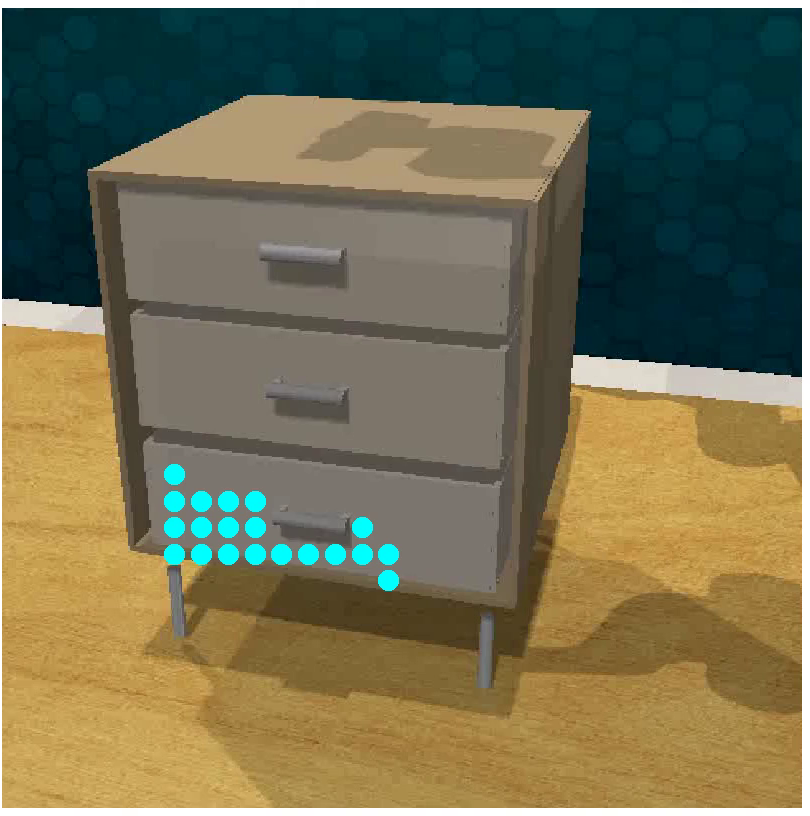
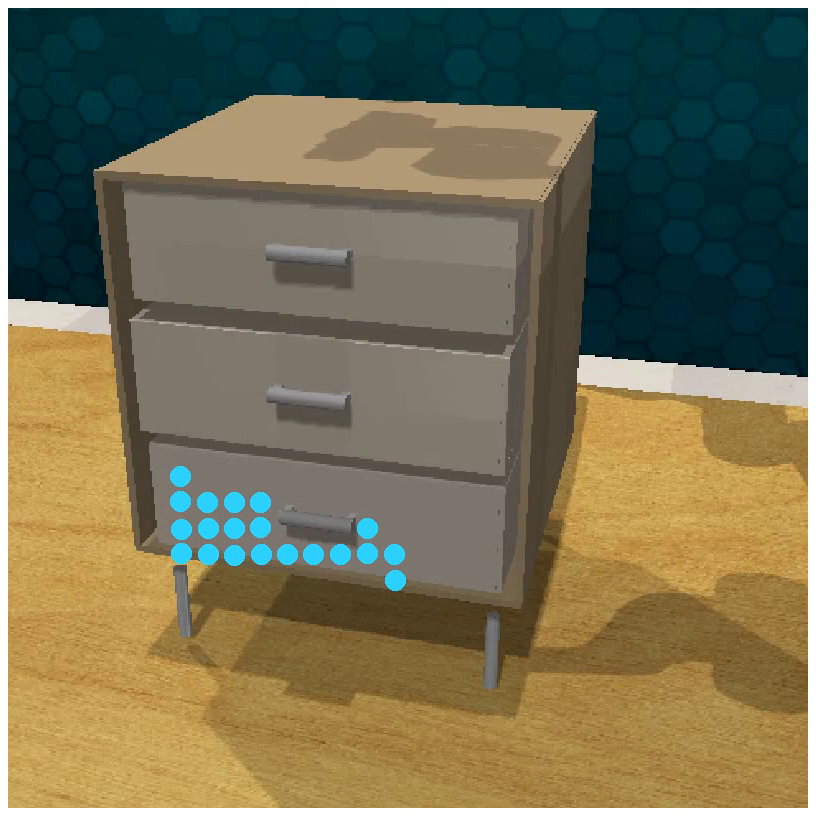
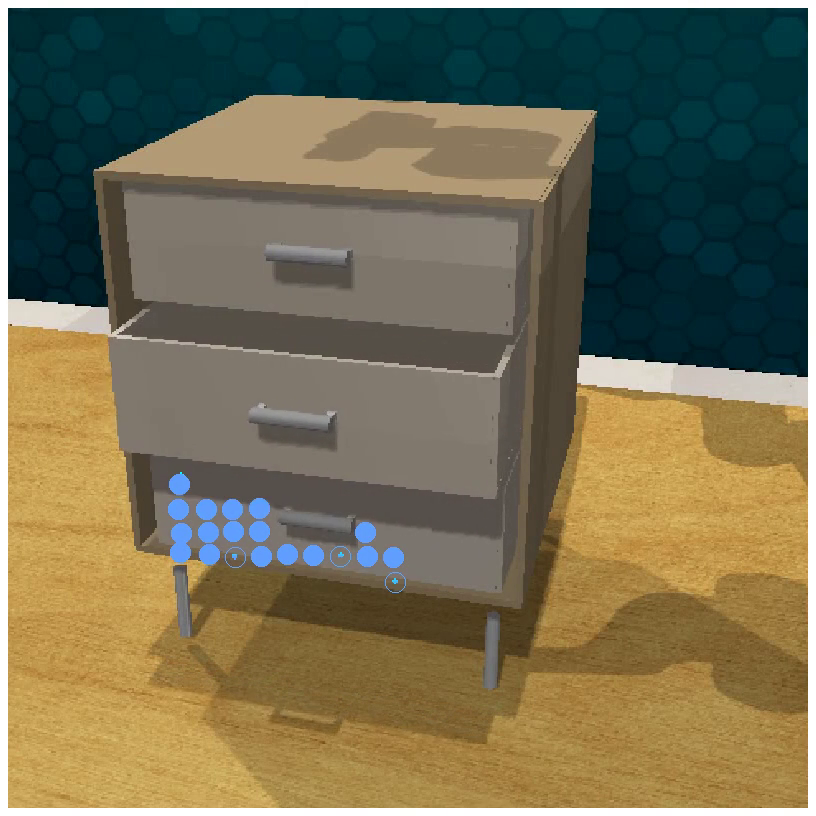
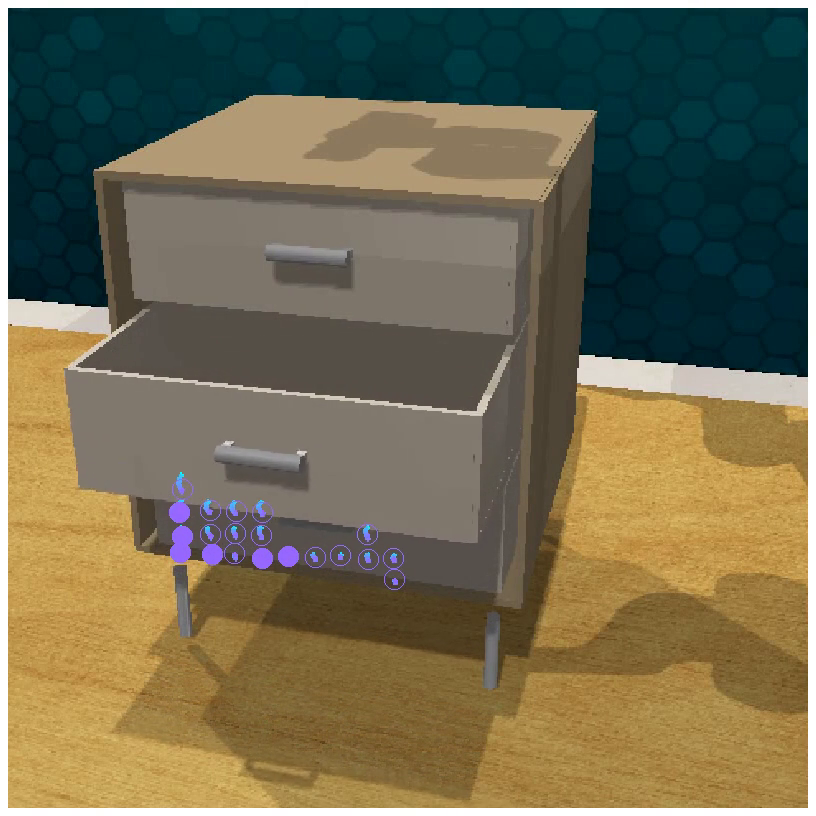
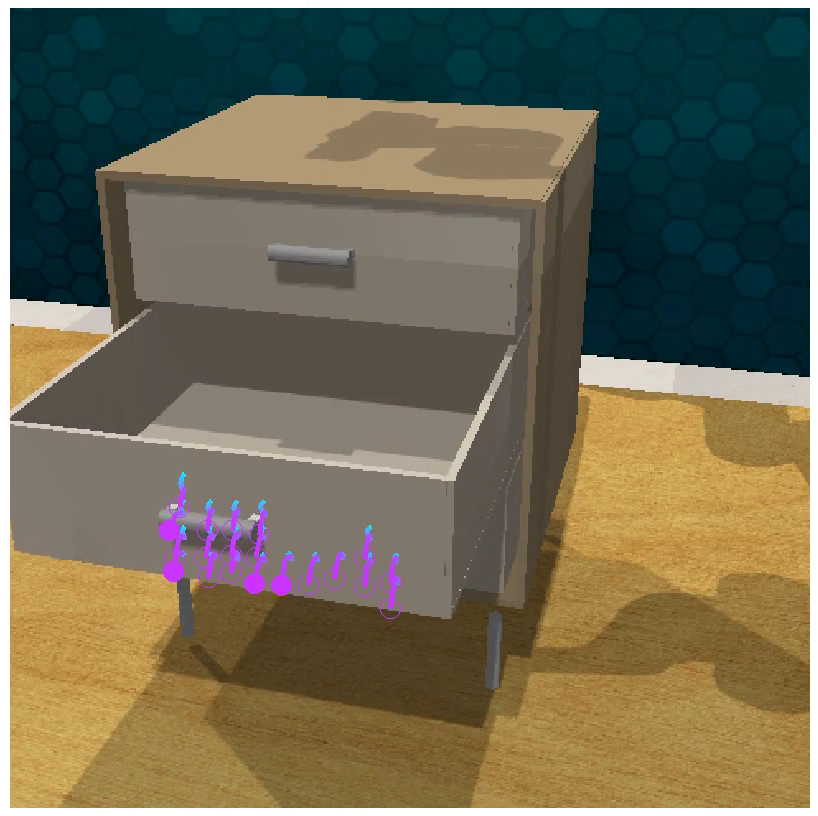
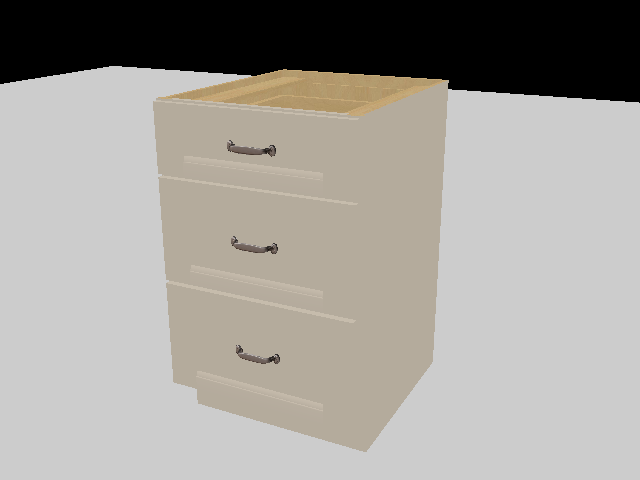
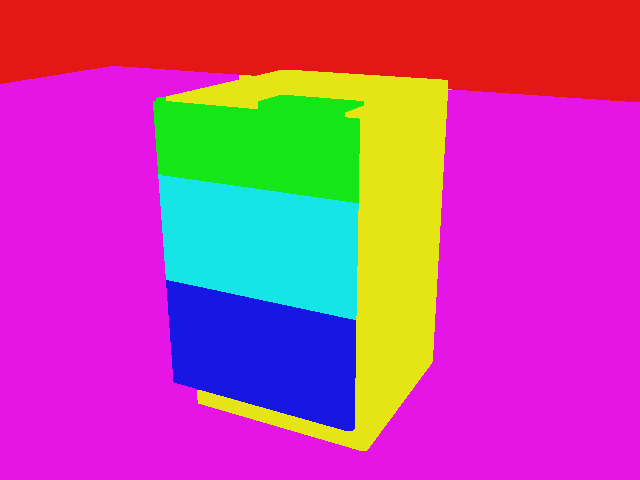

In [ ]:
extractor.load_prompt_parts()

In [ ]:
extractor.load_prediction()

{'img_description': [{'furniture_body': 'yellow in the segmented image'},
  {'drawer_3': 'green in the segmented image'},
  {'drawer_2': 'cyan in the segmented image'},
  {'drawer': 'blue in the segmented image'}],
 'gt_object': 'The object is a three-drawer cabinet. It has three drawers stacked vertically with handles on each drawer. The cabinet stands on four legs.',
 'affordance': 'The video shows the middle drawer of the cabinet being pulled out.',
 'part_name': 'drawer_2',
 'part_color': 'cyan'}

## Joint Prediction

In [ ]:
joint_art = steps["Joint Articulation"]
joint_actors = joint_art["Joint actor"]
joint_critics = joint_art["Joint critic"]


assert len(joint_actors) == len(joint_critics)
print(f"Joint prediction runs for {len(joint_actors)} iteration(s)")

Joint prediction runs for 1 iteration(s)


In [ ]:
joint_codes = [joint_actor.load_prediction() for joint_actor in joint_actors]
joint_preds = [joint_actor.load_predicted_rendering() for joint_actor in joint_actors]
joint_feedbacks = [json.dumps(joint_critic.load_prediction(),
                             indent=4) for joint_critic in joint_critics]

BEFORE FILTER VIDEO ['video_furniture_body_to_drawer_2_frontview.mp4']


/home/link/miniconda3/envs/articulate-anything-clean/lib/python3.9/site-packages/cotracker/models/build_cotracker.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_

Video saved to ./results/video/drawer_RL_Bench/joint_actor/iter_0/seed_0/aug_video_furniture_body_to_drawer_2_frontview.mp4


""

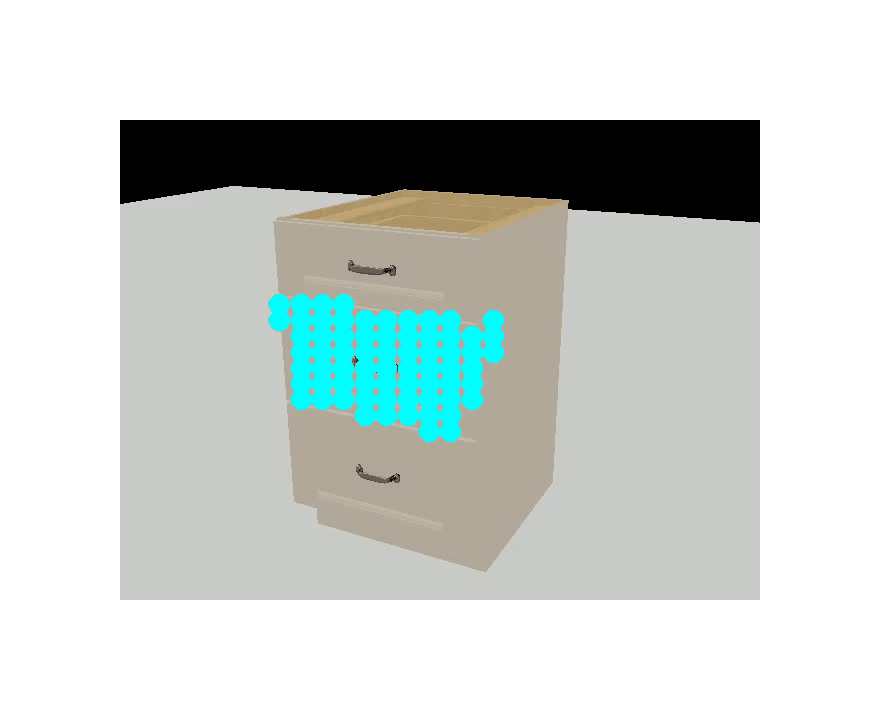

╷  
                                                                                                     │  
╶────────────────────────────────────────────────────────────────────────────────────────────────────┼─╴
 from articulate_anything.api.odio_urdf import *                                                     │  
                                                                                                     │  
 def partnet_44962(input_dir, links):                                                                │  
     pred_robot = Robot(input_dir=input_dir, name="cabinet")                                         │  
     pred_robot.add_link(links['base'])                                                              │  
     pred_robot.add_link(links['furniture_body'])                                                    │  
     pred_robot.add_joint(Joint("base_to_furniture_body",                                            │  
                          Parent("base"),                                                            │  
                          Child("furniture_body"),                                                   │  
                          type="fixed"),                                                             │  
                          )                                                                          │  
                                                                                                     │  
     # Add the drawers and place them in front of the furniture body                                 │  
     for drawer_idx in range(3):                                                                     │  
         drawer_link = "drawer" if drawer_idx == 0 else f"drawer_{drawer_idx+1}"                     │  
         pred_robot.add_link(links[drawer_link])                                                     │  
         pred_robot.place_relative_to(drawer_link, 'furniture_body',                                 │  
                                      placement="front",                                             │  
                                      clearance=0.0)                                                 │  
                                                                                                     │  
     # ====================JOINT PREDICTION====================                                      │  
     target_drawer_link = "drawer_2"                                                                 │  
     lower_point = [0, 0, 0]  # the drawer is fully retracted                                        │  
     bbox = pred_robot.get_bounding_boxes([target_drawer_link], include_dim=True)[target_drawer_link]│  
     bbox_dim = bbox[1]                                                                              │  
     upper_point = [bbox_dim["length"], 0, 0]  # the drawer is fully extended along the x-axis       │  
                                                                                                     │  
     pred_robot.make_prismatic_joint(                                                                │  
         target_drawer_link, "furniture_body", lower_point, upper_point                              │  
     )                                                                                               │  
     return pred_robot                                                                               │  
                                                                                                     ╵

╷ 
                                                                                                                │ 
╶───────────────────────────────────────────────────────────────────────────────────────────────────────────────┼╴
 {                                                                                                              │ 
     "gt_description": "The motion trace indicates the drawer slides out in a straight line along the forward-b…│ 
     "pred_description": "The motion trace shows the drawer slides out in a straight line along the forward-bac…│ 
     "candidate_function_description": "The `candidate_function` uses `make_prismatic_joint`, which is correct …│ 
     "failure_reason": "success",                                                                               │ 
     "improvement_suggestion": "None",                                                                          │ 
     "realism_rating": 10                                                                                       │ 
 }                                                                                                              │ 
                                                                                                                ╵

In [ ]:
show_videos(joint_preds, width=512, height=512)
display_codes(joint_codes)
display_codes(joint_feedbacks)